In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob


In [8]:
df = pd.read_csv("Student_Satisfaction_Survey.csv", encoding="latin1")
df.head()


,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [9]:
# Check dataset information: columns, types, missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   SN                    580 non-null    int64 
 1   Total Feedback Given  580 non-null    int64 
 2   Total Configured      580 non-null    int64 
 3   Questions             580 non-null    object
 4   Weightage 1           580 non-null    int64 
 5   Weightage 2           580 non-null    int64 
 6   Weightage 3           580 non-null    int64 
 7   Weightage 4           580 non-null    int64 
 8   Weightage 5           580 non-null    int64 
 9   Average/ Percentage   580 non-null    object
 10  Course Name           580 non-null    object
 11  Basic Course          580 non-null    object
dtypes: int64(8), object(4)
memory usage: 54.5+ KB


In [10]:
# Describe statistics for numeric columns
df.describe()

,SN,Total Feedback Given,Total Configured,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,10.500000,14.310345,92.517241,0.527586,1.187931,2.537931,5.082759,4.974138
std,5.771259,16.488031,114.491780,1.305336,1.686334,3.193302,7.288293,6.494931
min,1.000000,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.750000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,10.500000,7.000000,42.000000,0.000000,0.000000,1.000000,3.000000,3.000000
75%,15.250000,17.000000,123.000000,1.000000,2.000000,3.250000,6.000000,6.000000
max,20.000000,74.000000,559.000000,19.000000,8.000000,26.000000,52.000000,38.000000


In [11]:
# Identify missing values in each column
df.isnull().sum()

,0
SN,0
Total Feedback Given,0
Total Configured,0
Questions,0
Weightage 1,0
Weightage 2,0
Weightage 3,0
Weightage 4,0
Weightage 5,0
Average/ Percentage,0


In [12]:
# Drop irrelevant columns and standardize column names
df.drop(columns=['Unnamed: 0', 'Student ID'], inplace=True, errors='ignore')

In [13]:
df.columns = df.columns.str.strip()

In [14]:
# Convert 'Average/ Percentage' to numeric 'Average Score'
df['Average Score'] = (df['Average/ Percentage']
                       .str.split('/')
                       .str[0]
                       .astype(float))

In [15]:
# Define rating columns and compute average score per column
rating_cols = [
    'Weightage 1',
    'Weightage 2',
    'Weightage 3',
    'Weightage 4',
    'Weightage 5',
    'Total Feedback Given',
    'Total Configured'
]

In [16]:
avg_scores = df[rating_cols].mean().sort_values(ascending=False)
avg_scores

,0
Total Configured,92.517241
Total Feedback Given,14.310345
Weightage 4,5.082759
Weightage 5,4.974138
Weightage 3,2.537931
Weightage 2,1.187931
Weightage 1,0.527586


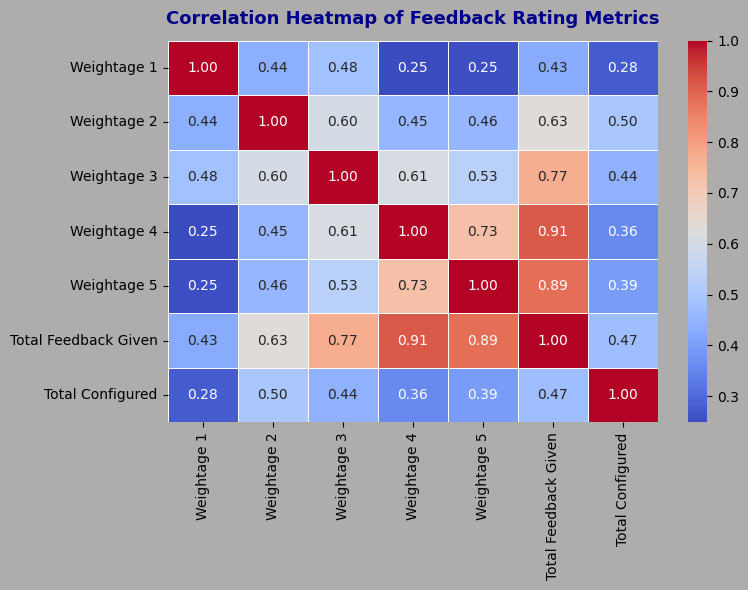

In [17]:
# Visualize correlation between rating questions
plt.figure(figsize=(8,6), facecolor='#afadab')
sns.heatmap(
    df[rating_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Feedback Rating Metrics",pad=12,
          fontsize=13, fontweight='semibold', color='darkblue')
plt.tight_layout()
plt.show()


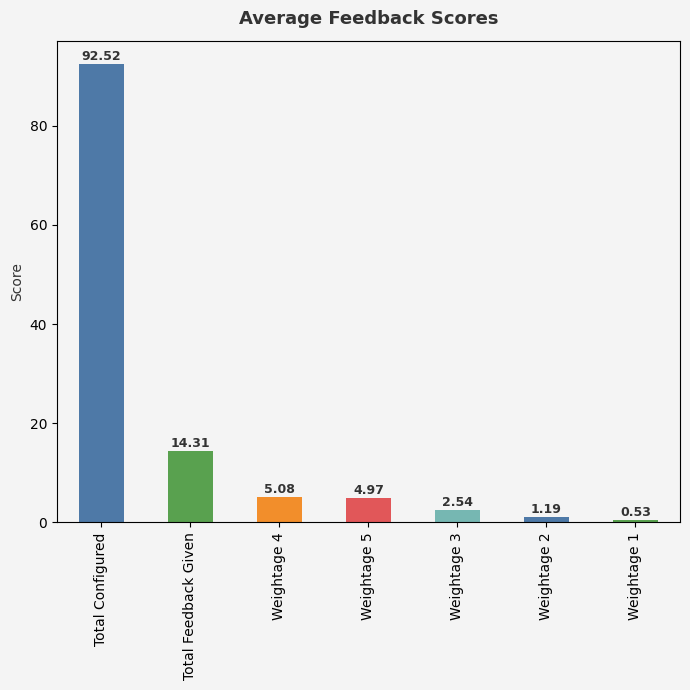

In [18]:
fig, ax = plt.subplots(figsize=(7,7), facecolor='#f4f4f4')
ax.set_facecolor('#f4f4f4')

avg_scores.plot(
    kind='bar',
    ax=ax,
    color=['#4E79A7', '#59A14F', '#F28E2B', '#E15759', '#76B7B2']
)

ax.set_title("Average Feedback Scores",
             pad=12, fontsize=13, fontweight='semibold', color='#333333')
ax.set_ylabel("Score", color='#333333')

for i, v in enumerate(avg_scores):
    ax.text(i, v + 0.2, f"{v:.2f}",
            ha='center', va='bottom', fontsize=9,
            color='#333333', fontweight='semibold')

plt.tight_layout()
plt.show()


In [19]:
df['Score'] = df['Average Score'].round().astype(int)
score_counts = df['Score'].value_counts().sort_index()

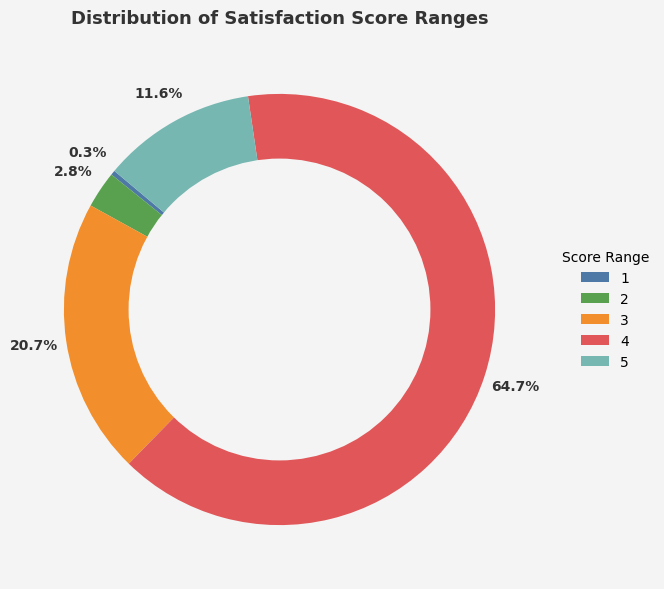

In [20]:
colors = ['#4E79A7', '#59A14F', '#F28E2B', '#E15759', '#76B7B2']

plt.figure(figsize=(7,7), facecolor='#f4f4f4')
wedges, _, _ = plt.pie(
    score_counts,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=1.15,
    textprops={'fontweight':'bold','fontsize':10,'color':'#333333'}
)

plt.gca().add_artist(plt.Circle((0,0), 0.70, fc='#f4f4f4'))

plt.legend(
    wedges, score_counts.index, title="Score Range",
    loc="center left", bbox_to_anchor=(1, 0.5),
    facecolor='#f4f4f4', edgecolor='#f4f4f4'
)

plt.title("Distribution of Satisfaction Score Ranges",
          pad=12, fontsize=13, fontweight='semibold', color='#333333')
plt.show()


In [21]:
course_avg = (
    df.groupby('Course Name')['Average Score']
      .mean()
      .sort_values(ascending=False)
)

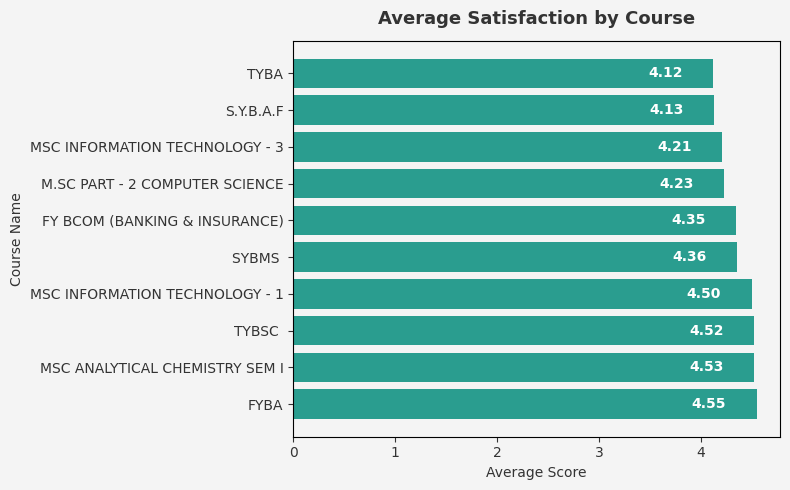

In [22]:
fig, ax = plt.subplots(figsize=(8,5), facecolor='#f4f4f4')
ax.set_facecolor('#f4f4f4')

bars = ax.barh(
    course_avg.head(10).index,
    course_avg.head(10).values,
    color='#2A9D8F'
)

ax.set_title("Average Satisfaction by Course",
             pad=12, fontsize=13, fontweight='semibold', color='#333333')
ax.set_xlabel("Average Score", color='#333333')
ax.set_ylabel("Course Name", color='#333333')
ax.tick_params(colors='#333333')

for bar in bars:
    width = bar.get_width()
    ax.text(width - 0.3, bar.get_y() + bar.get_height()/2,
            f"{width:.2f}", va='center', ha='right',
            color='white', fontweight='bold')

plt.tight_layout()
plt.show()


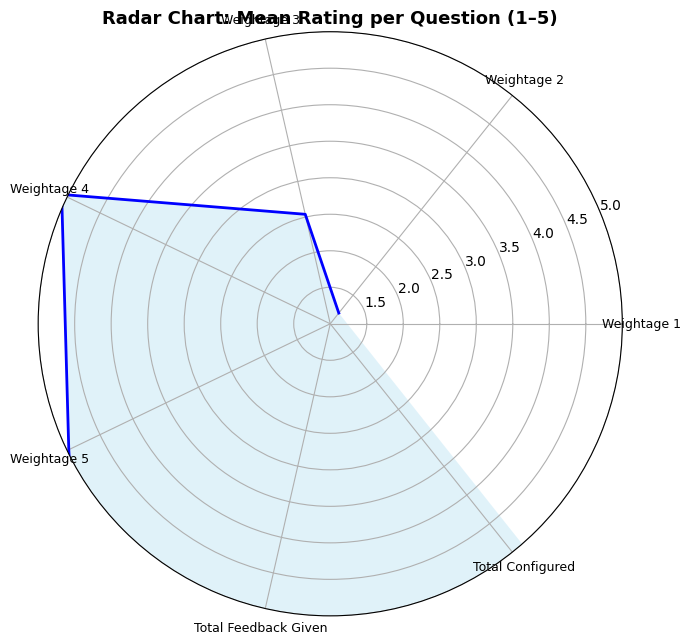

In [40]:
# 8.5 Radar chart of mean scores (gives a quick visual of strengths/weaknesses)
# Radar requires equal-length and numeric: we'll use means values
means_vals = df[rating_cols].mean().values
labels = rating_cols
num_vars = len(labels)



# Mean values (should match the number of labels)
means_vals = df[labels].mean().tolist()

# Close the loop for radar chart (add first element again)
means_vals += means_vals[:1]
angles = np.linspace(0, 2 * np.pi, len(labels) + 1)

# Plot
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, polar=True)
ax.plot(angles, means_vals, linewidth=2, color='blue')
ax.fill(angles, means_vals, color='skyblue', alpha=0.25)

# Set labels and limits
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
ax.set_ylim(1, 5)
ax.set_title('Radar Chart: Mean Rating per Question (1–5)', size=13, weight='bold')

plt.tight_layout()
plt.show()